# Seaborn
---
1.1 Introducción a Seaborn

Seaborn es una biblioteca de visualización de datos basada en Matplotlib. Su objetivo es simplificar la creación de gráficos atractivos y concisos. Seaborn se integra naturalmente con DataFrames de Pandas y proporciona paletas de colores estilizadas, lo que facilita la exploración visual de datos.

**Ventajas frente a otras bibliotecas de visualización:**

- Sintaxis más simple y concisa.
- Integración directa con DataFrames de Pandas.
- Estilo estéticamente agradable por defecto.
- Herramientas específicas para gráficos estadísticos.


In [2]:
%mamba install numpy pandas matplotlib seaborn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 3.675 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge


%pip install numpy pandas matplotlib seaborn

**Diferencias de pip y mamba**
- %pip: Gestor de paquetes de Python, NO maneja entornos virtuales
- %mamba: Gestor de paquetes compatible con Conda, Si maneja entornos virtuales

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
import numpy as np

Comenzemos creando un dataframe para trabajar:

In [7]:
# lista de bases de datos
nombres_datasets = sns.get_dataset_names()

print(nombres_datasets)

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [8]:
# Cargar el conjunto de datos Iris
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Cada observación incluye cuatro características (variables):

- Longitud del sépalo en centímetros.
- Ancho del sépalo en centímetros.
- Longitud del pétalo en centímetros.
- Ancho del pétalo en centímetros.

El objetivo típico en el análisis de este conjunto de datos es clasificar las especies de iris en función de estas cuatro características. El conjunto de datos Iris se utiliza comúnmente como un ejercicio de clasificación en la enseñanza de algoritmos de aprendizaje automático y técnicas estadísticas debido a su simplicidad y claridad en la clasificación.

# **Gráficos básicos con seaborn**

## Gráfico de barras


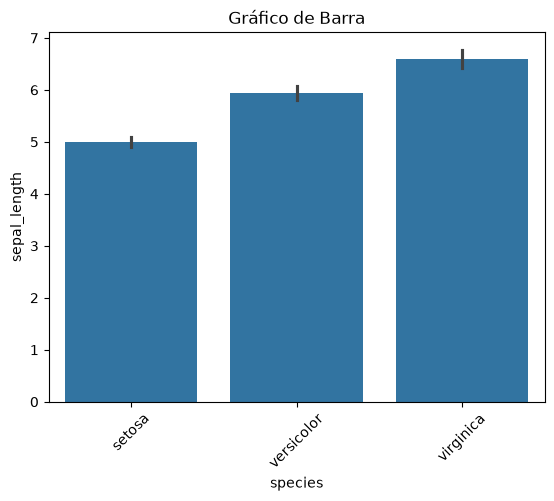

In [9]:
# Crear un gráfico de barra simple
sns.barplot(x='species',y='sepal_length', data=iris)
plt.xticks(rotation=45)
plt.title('Gráfico de Barra')
plt.show()


Veamos como ademas podemos crear un grafico para cada categoria usando catplot() (este funciona para datos categoricos, para numericos veremos otro.

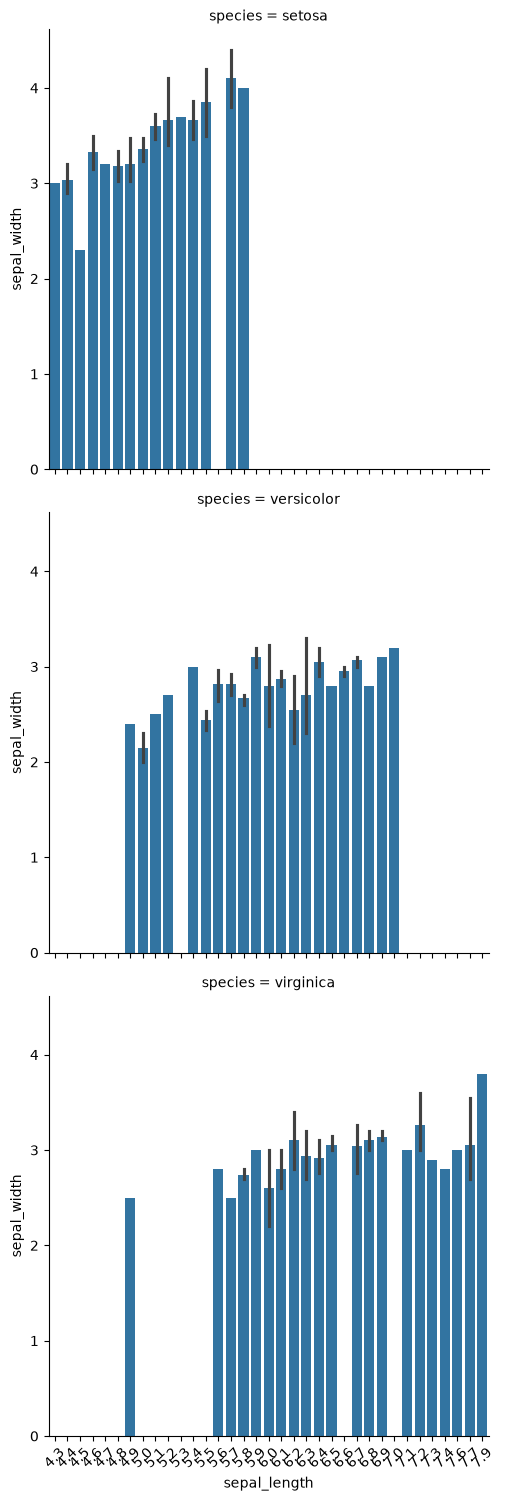

In [10]:
# Uso de relplot para un gráfico de barra
sns.catplot(x='sepal_length', y='sepal_width', kind='bar', data=iris,row='species') #Vemos que nos ha creado un subgrafico para cada categoria - probasr con row
plt.xticks(rotation=45)
plt.show()


## **Histograma**
Con el histograma podemos ver la distribucion de los datos.

<Axes: xlabel='sepal_length', ylabel='Count'>

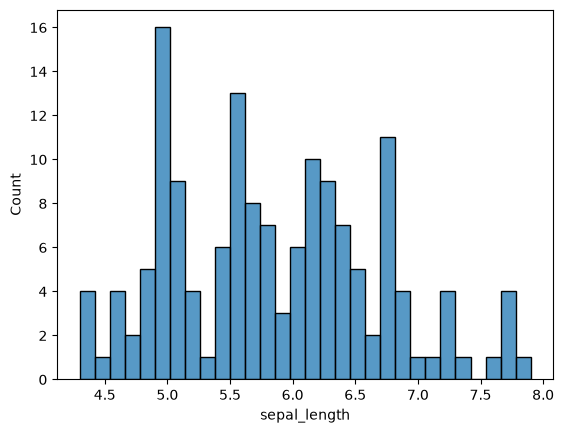

In [11]:
sns.histplot(x='sepal_length',data=iris,bins=30)

Si queremos subdividir por cada especie de planta podemos hacer lo siguiente

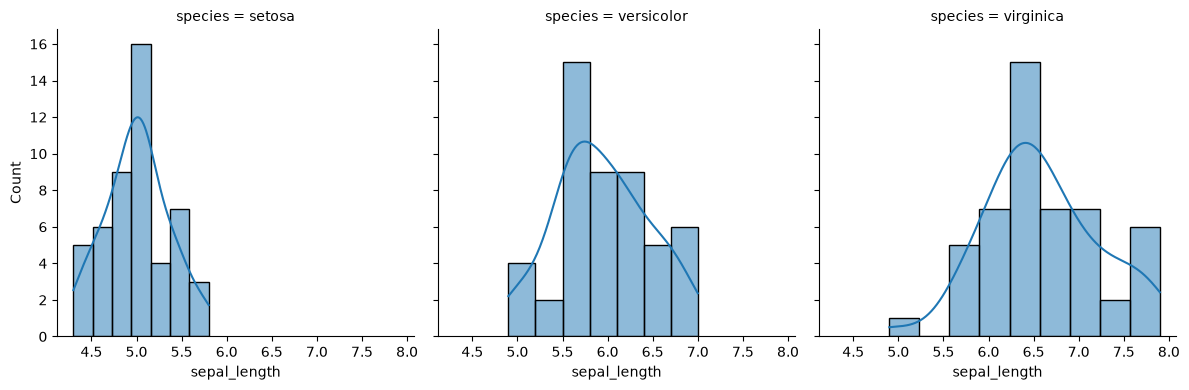

In [16]:
g = sns.FacetGrid(iris, col="species", height=4, aspect=1)
g.map(sns.histplot, 'sepal_length', kde=True)

Otra forma de ver la distribucion de los valores de una variable es:

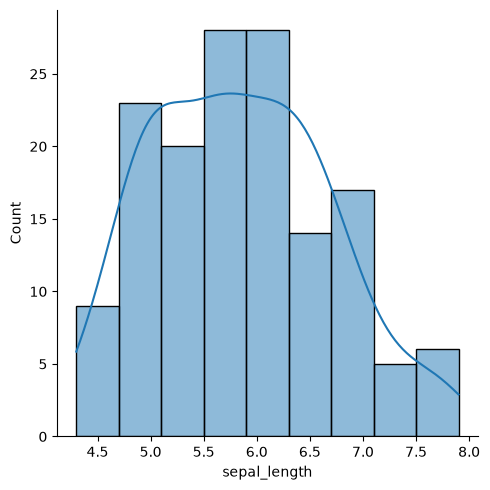

In [17]:
sns.displot(x='sepal_length',data=iris,kde=True)

## Gráfico de lineas

/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)
/lib/python3.13/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  func(*plot_args, **plot_kwargs)


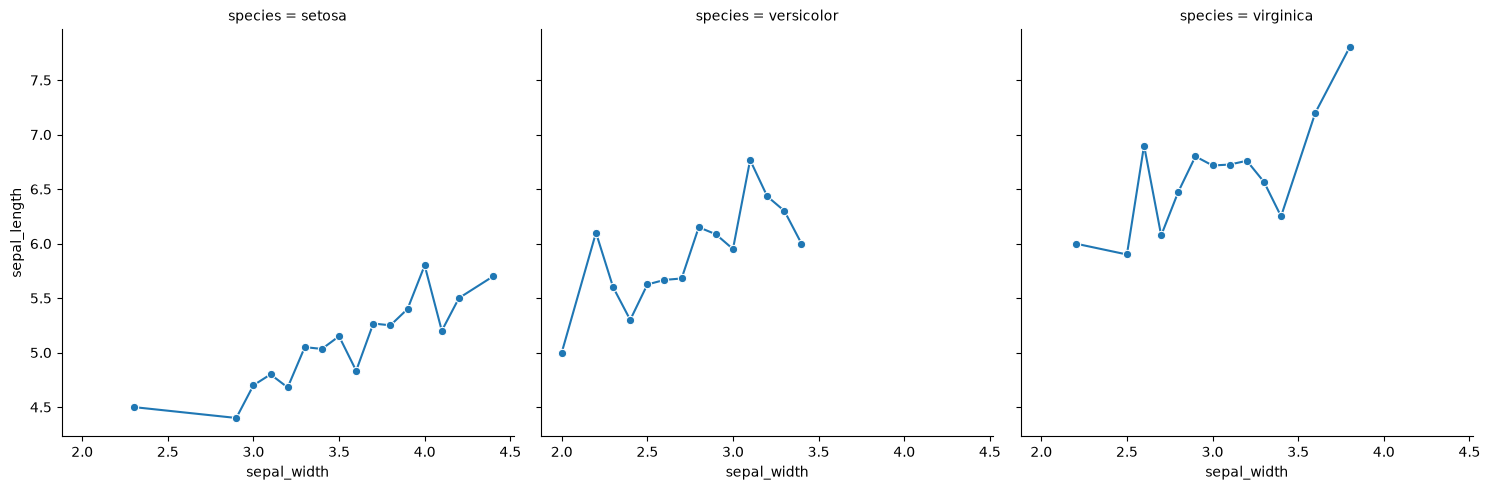

In [18]:
sns.relplot(data=iris, x='sepal_width', y="sepal_length", label="Sepal Length", marker='o',kind='line',col='species',ci=None) #Lo hacemos asi ya que no tenemos fechas en que apoyarnos para hace runa serie temporal


## Gráfico de violin

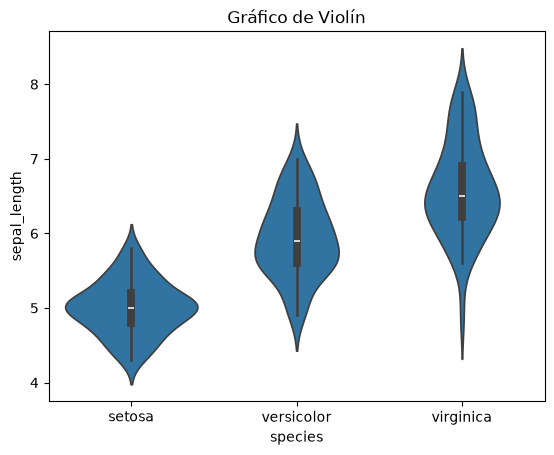

In [19]:
# Crear un gráfico de violín
sns.violinplot(x='species', y='sepal_length', data=iris)
plt.title('Gráfico de Violín')
plt.show()


## **Mapas de calor**

Estos son muy utiles para ver la correlacion de variables por ejemplo para modelos de IA.

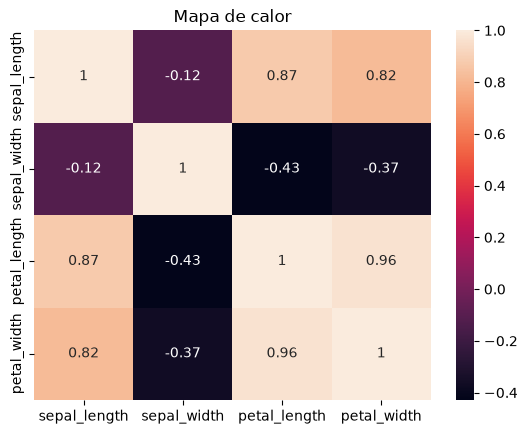

In [21]:
# Crear la matriz de correlación solo con variables numéricas
correlation_matrix = iris.corr(numeric_only=True)

# Crear el mapa de calor
sns.heatmap(correlation_matrix, annot=True)

plt.title("Mapa de calor")
plt.show()


## **Gráfico de densidad**

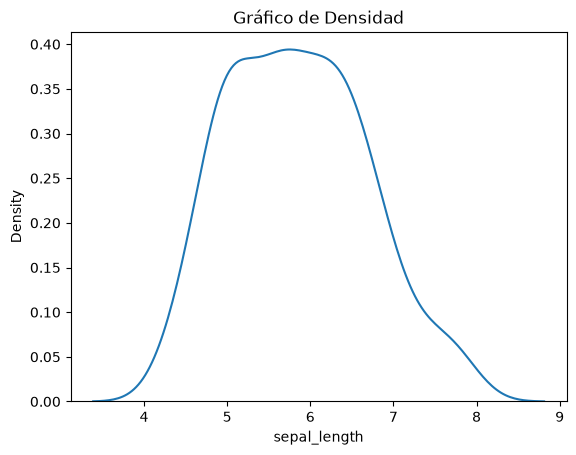

In [22]:
# Crear un gráfico de densidad
sns.kdeplot(iris['sepal_length'])
plt.title('Gráfico de Densidad')
plt.show()


## **Gráfico de regresión**

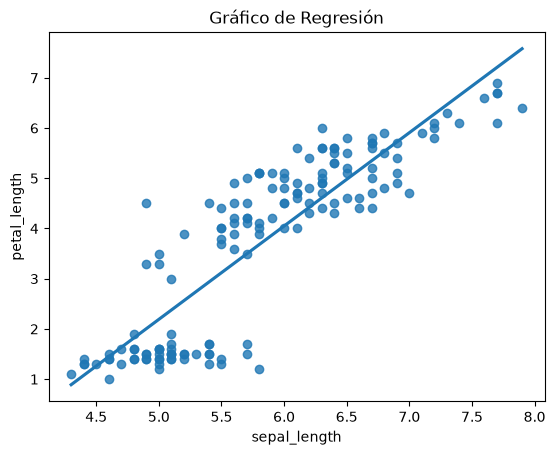

In [23]:
# Crear un gráfico de regresión
sns.regplot(x='sepal_length', y='petal_length', data=iris,ci=None)
plt.title('Gráfico de Regresión')
plt.show()


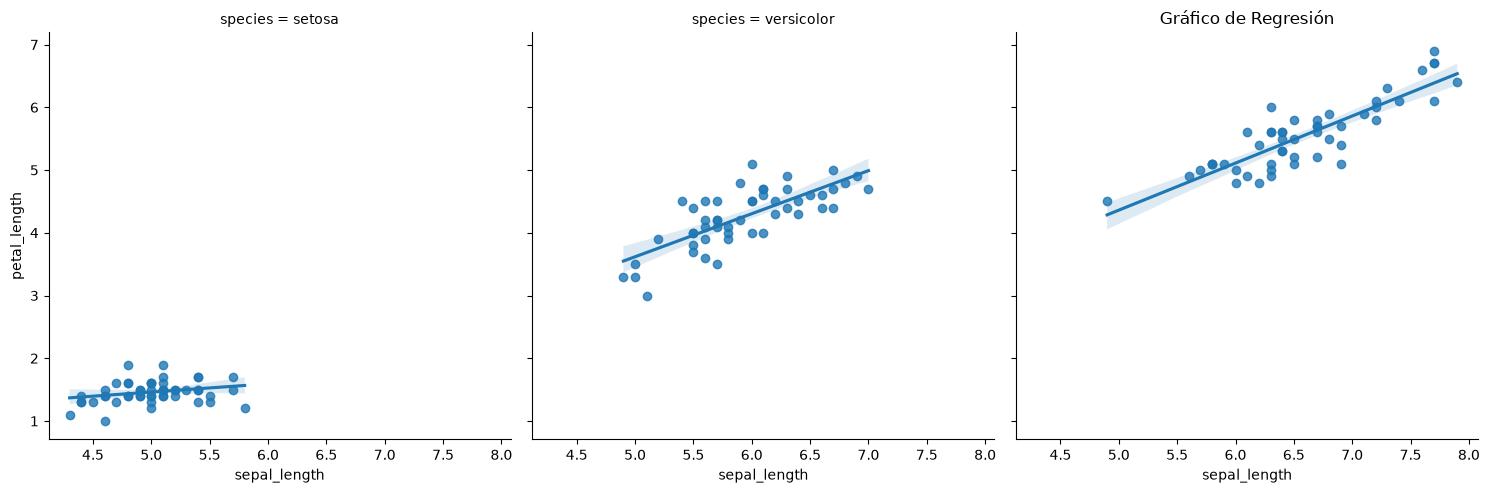

In [24]:
# Crear un gráfico de regresión
sns.lmplot(x='sepal_length', y='petal_length', data=iris,col='species')
plt.title('Gráfico de Regresión')
plt.show()


## **Gráficos de Pairplot**

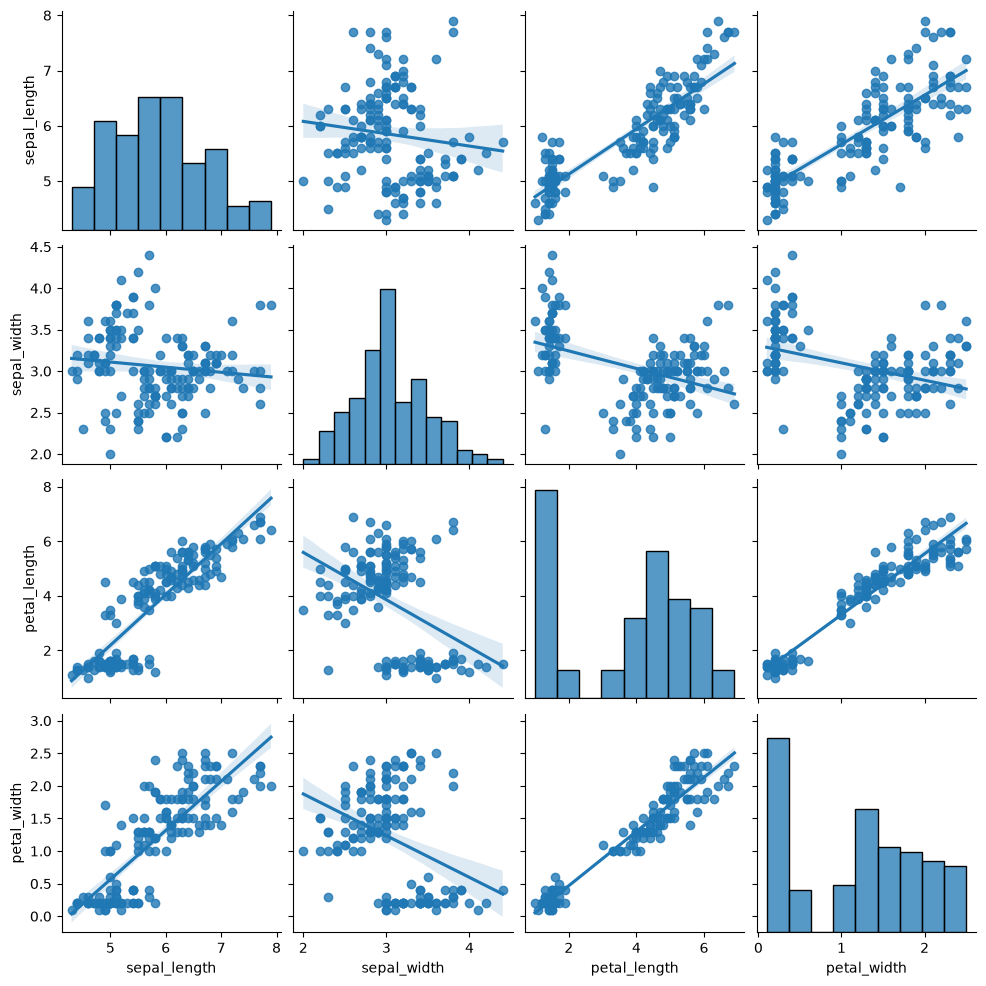

In [25]:
# Crear un gráfico de pairplot
sns.pairplot(iris,kind='reg',diag_kind='hist')


**Pairplot** muestra las relaciones bivariadas entre variables en un DataFrame.
Es una herramienta útil para identificar patrones y correlaciones en conjuntos de datos multivariados.

## **Boxplot**

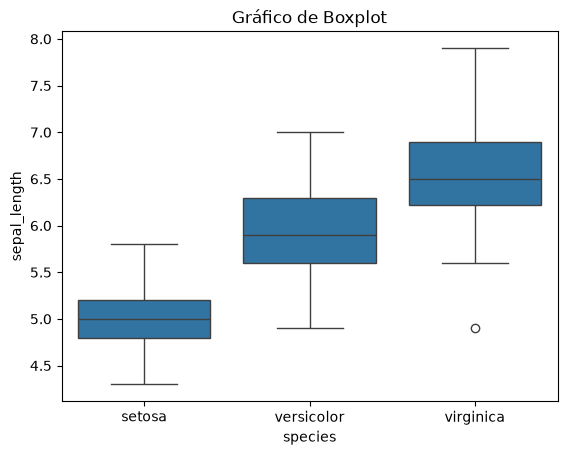

In [26]:
# Crear un gráfico de boxen
sns.boxplot(x='species', y='sepal_length', data=iris)
plt.title('Gráfico de Boxplot')
plt.show()


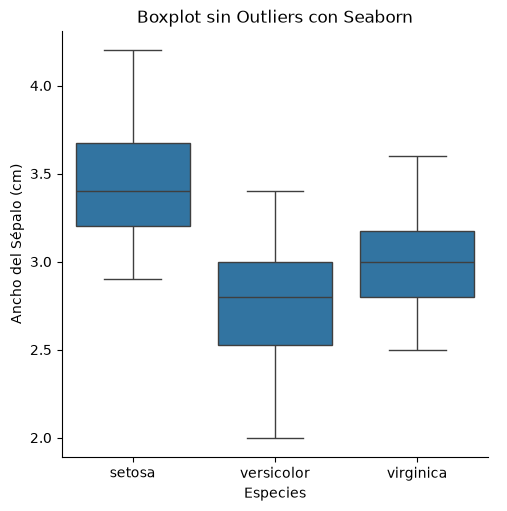

In [27]:
# Crear un boxplot sin mostrar outliers
sns.catplot(x='species', y='sepal_width',kind='box', data=iris,showfliers=False) #Para no mostrar outliers showfliers=False

# Personalizar el gráfico
plt.title('Boxplot sin Outliers con Seaborn')
plt.xlabel('Especies')
plt.ylabel('Ancho del Sépalo (cm)')

# Mostrar el gráfico
plt.show()

## **Joinplot**

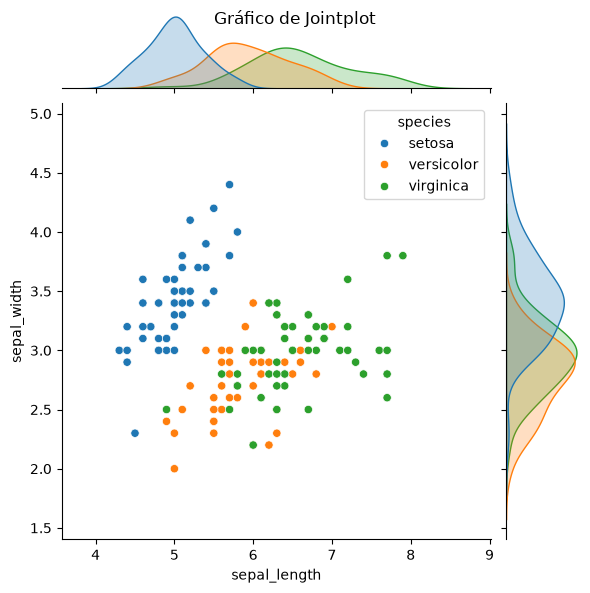

In [28]:
# Crear un gráfico de jointplot
sns.jointplot(x='sepal_length',y='sepal_width', data=iris, kind='scatter',hue='species')
plt.suptitle('Gráfico de Jointplot')
plt.show()


## Gráfico de dispersion
Vamos a ver como hacer un gráfico de dispersion y algunos parametros comunes a los gráficos de seaborn que pueden ser útiles.

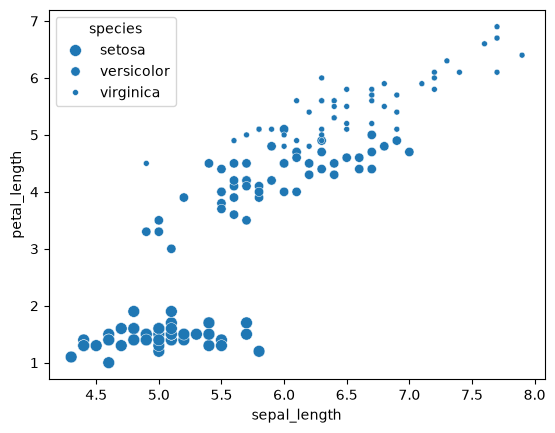

In [29]:
sns.scatterplot(x='sepal_length',y='petal_length',data=iris,size='species')
plt.show()

# **Configuración de los gráficos**


## **Modificar el estilo**

In [143]:
sns.set_style('white') #dark,

<Axes: xlabel='sepal_length', ylabel='petal_length'>

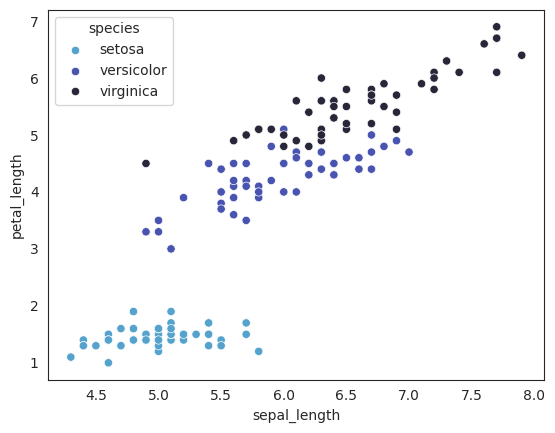

In [144]:
sns.scatterplot(x='sepal_length',y='petal_length',data=iris,hue='species')


## **Modificar la paleta de colores**

Para ver la paleta actual:

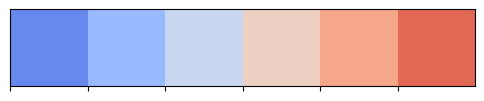

In [33]:
sns.palplot(sns.color_palette())

Para modificarla:

In [32]:
sns.set_palette('coolwarm') #'deep', 'muted', 'bright', 'pastel', 'dark', 'colorblind' 'coolwarm', 'RdBu_r', 'vlag', 'icefire', 'crest'

<Axes: xlabel='sepal_length', ylabel='petal_length'>

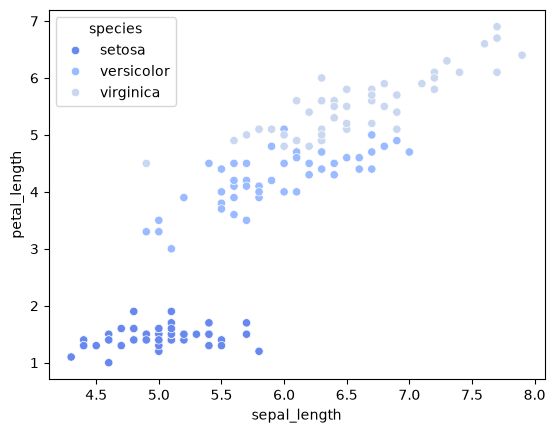

In [34]:
sns.scatterplot(x='sepal_length',y='petal_length',data=iris,hue='species')


## **Gráfico de residuos**
Es muy útil para evaluar el fit de un modelo de IA tras haber sido entrenado

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

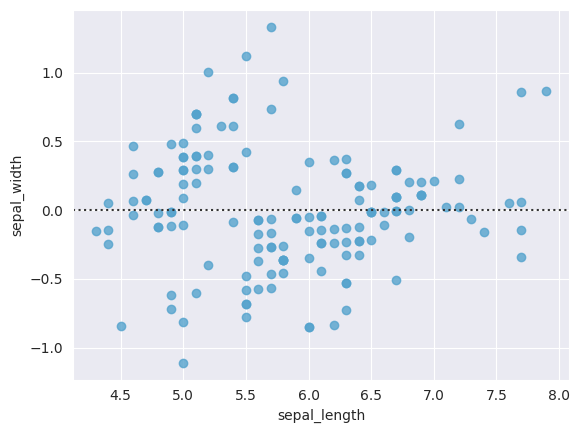

In [130]:
sns.residplot(x='sepal_length',y='sepal_width',data=iris)